# Regime and Attribution Analysis

Follow-up to `docs/memo.md`'s Results section, which reads the full-history backtest as "weak, honestly negative ... confidence is low in either direction." That verdict is a single number averaged over ~10.5 years and ~42-43 quarters per lag. This notebook asks two follow-on questions using data already committed (`data/processed/backtest_results.pkl`, `data/processed/quarter_asset_detail.csv`, `data/processed/prices.parquet`) — no re-run of the backtest:

1. **Sub-period robustness**: is the weak full-sample Sharpe/IC consistently weak across the window, or does it hide a regime break?
2. **Attribution**: is the spread's return coming from many small, independent bets (consistent with a genuine breadth-momentum signal), or concentrated in a handful of names/themes?

All the data-wrangling (`quarter_asset_detail`, `subperiod_stats`, `subperiod_navs`) lives in `src/detail.py`, tested in `tests/test_detail.py` — this notebook only calls those functions, visualizes, and interprets, per this repo's convention (`notebooks/` = exploration, `src/` = reusable logic).

In [1]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, "..")
from src import detail
from src.backtest import LAG_DAYS_GRID, PRIMARY_COST_BPS, PRIMARY_LAG_DAYS

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (10, 4)

with open("../data/processed/backtest_results.pkl", "rb") as fh:
    payload = pickle.load(fh)
results = payload["results"]
meta = payload["meta"]
meta

{'panel': 'data/processed/13f_panel_full.parquet',
 'panel rows': '81,812,809',
 'window': '2015-09-30 to 2026-03-31',
 'price universe (tickers)': '515',
 'lag_days grid': [45, 60, 90],
 'cost_bps grid': [0, 5, 10, 25],
 'n_quantiles': 10,
 'generated': '2026-08-15',
 'quick_mode': False}

## 1. Sub-period robustness

Split the closed-quarter history into 2 and 3 roughly-equal-count chunks (by quarter count, not calendar time, to keep sample sizes balanced), for every lag in the grid, and recompute the same performance stats / IC aggregation the full-window backtest reports — `subperiod_stats_grid` reuses `backtest.apply_transaction_costs`/`_stitch`/`performance_stats` directly, no new stats logic.

In [2]:
grid = detail.subperiod_stats_grid(results, n_splits_list=(2, 3))
cols = ["lag_days", "n_splits", "chunk", "start_period", "end_period", "n_quarters",
        "annualized_return", "sharpe", "max_drawdown", "mean_ic", "pct_positive_ic", "n_ic_quarters"]
grid[cols]

,lag_days,n_splits,chunk,start_period,end_period,n_quarters,annualized_return,sharpe,max_drawdown,mean_ic,pct_positive_ic,n_ic_quarters
0,45,2,0,2015-09-30,2020-12-31,22,0.081957,0.563518,-0.216516,0.045124,0.590909,22
1,45,2,1,2021-03-31,2026-03-31,21,0.036254,0.202992,-0.248274,-0.013167,0.523810,21
2,45,3,0,2015-09-30,2019-03-31,15,0.066635,0.721838,-0.077425,0.044012,0.600000,15
3,45,3,1,2019-06-30,2022-09-30,14,-0.016737,-0.094272,-0.277514,-0.010115,0.428571,14
4,45,3,2,2022-12-31,2026-03-31,14,0.134993,0.671876,-0.206562,0.014118,0.642857,14
5,60,2,0,2015-09-30,2020-09-30,21,-0.009335,-0.055038,-0.333704,0.023266,0.619048,21
6,60,2,1,2020-12-31,2025-12-31,21,0.064344,0.369291,-0.342890,0.008585,0.714286,21
7,60,3,0,2015-09-30,2018-12-31,14,0.010324,0.080541,-0.204245,0.034773,0.642857,14
8,60,3,1,2019-03-31,2022-06-30,14,-0.099450,-0.476933,-0.553918,-0.035702,0.571429,14
9,60,3,2,2022-09-30,2025-12-31,14,0.192183,1.135948,-0.125504,0.048705,0.785714,14


### Reading the 3-way split

A consistent pattern shows up **across all three lags**, not just the primary one:

| Chunk | Roughly | Sharpe (45d / 60d / 90d) |
|---|---|---|
| 0 | 2015-09-30 to ~2019 | 0.72 / 0.08 / 0.10 |
| 1 | ~2019 to ~2022 (COVID crash + 2022 bear market) | **-0.09 / -0.48 / -0.30** |
| 2 | ~2022 to 2026-03-31 | **0.67 / 1.14 / 1.14** |

The full-sample Sharpe (0.15 at the primary 60d/10bps combination) is a weighted average of a genuinely bad middle regime and a genuinely strong recent one — not a uniformly weak signal. The 2-way split shows the same direction for 60d/90d (second half stronger than first) but *not* for 45d, where it flips — so the regime read is real but not perfectly clean across every lag/granularity, which is itself worth stating plainly rather than picking the split that tells the best story.

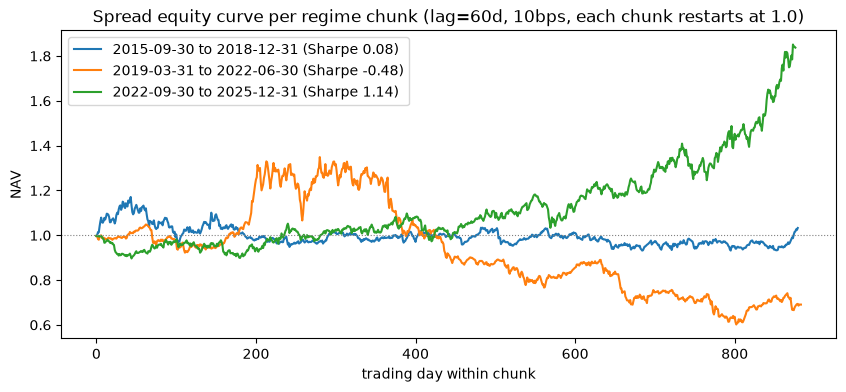

In [3]:
navs = detail.subperiod_navs(results, lag_days=PRIMARY_LAG_DAYS, cost_bps=PRIMARY_COST_BPS, n_splits=3)
stats3 = detail.subperiod_stats(results, lag_days=PRIMARY_LAG_DAYS, cost_bps=PRIMARY_COST_BPS, n_splits=3)

fig, ax = plt.subplots()
for nav, (_, row) in zip(navs, stats3.iterrows()):
    label = f"{row['start_period'].date()} to {row['end_period'].date()} (Sharpe {row['sharpe']:.2f})"
    ax.plot(range(len(nav)), nav.values, label=label)
ax.set_title(f"Spread equity curve per regime chunk (lag={PRIMARY_LAG_DAYS}d, {PRIMARY_COST_BPS}bps, each chunk restarts at 1.0)")
ax.set_xlabel("trading day within chunk")
ax.set_ylabel("NAV")
ax.legend()
ax.axhline(1.0, color="grey", linewidth=0.8, linestyle=":")
plt.show()

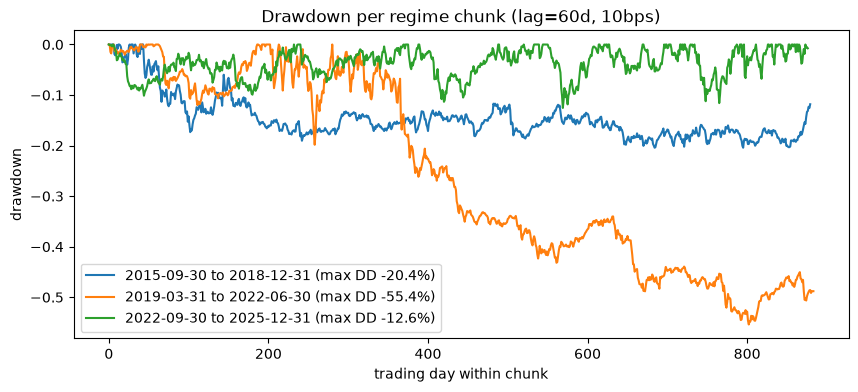

In [4]:
fig, ax = plt.subplots()
for nav, (_, row) in zip(navs, stats3.iterrows()):
    drawdown = nav / nav.cummax() - 1
    label = f"{row['start_period'].date()} to {row['end_period'].date()} (max DD {row['max_drawdown']:.1%})"
    ax.plot(range(len(drawdown)), drawdown.values, label=label)
ax.set_title(f"Drawdown per regime chunk (lag={PRIMARY_LAG_DAYS}d, {PRIMARY_COST_BPS}bps)")
ax.set_xlabel("trading day within chunk")
ax.set_ylabel("drawdown")
ax.legend()
plt.show()

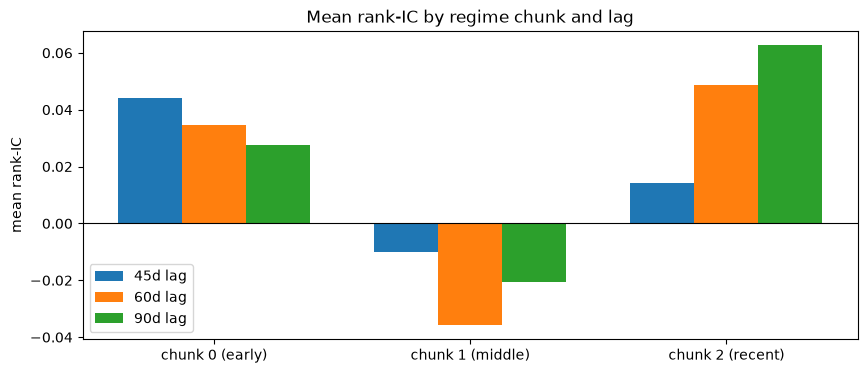

In [5]:
fig, ax = plt.subplots()
width = 0.25
for i, lag in enumerate(LAG_DAYS_GRID):
    s = detail.subperiod_stats(results, lag_days=lag, cost_bps=PRIMARY_COST_BPS, n_splits=3)
    xs = [x + i * width for x in range(len(s))]
    ax.bar(xs, s["mean_ic"], width=width, label=f"{lag}d lag")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks([x + width for x in range(3)])
ax.set_xticklabels(["chunk 0 (early)", "chunk 1 (middle)", "chunk 2 (recent)"])
ax.set_ylabel("mean rank-IC")
ax.set_title("Mean rank-IC by regime chunk and lag")
ax.legend()
plt.show()

**Read**: the IC pattern echoes the Sharpe pattern — mean IC turns negative for 60d/90d in the middle chunk and recovers (highest of all three chunks) in the recent one. This is more consistent with genuine regime-dependent efficacy than with the middle chunk being pure noise, though with only 14 quarters per 3-way chunk, sampling noise can't be ruled out on this evidence alone.

## 2. Attribution: what's actually driving the spread's return

Using `quarter_asset_detail.csv` (per-ticker, per-quarter return and contribution, primary lag).

In [6]:
asset_detail = pd.read_csv("../data/processed/quarter_asset_detail.csv")
d = asset_detail[(asset_detail["lag_days"] == PRIMARY_LAG_DAYS) & (~asset_detail["dropped"])].copy()

print("Top 10 single (ticker, quarter) contributions by absolute size:")
top_single = d.reindex(d["contribution"].abs().sort_values(ascending=False).index).head(10)
top_single[["period_of_report", "ticker", "leg", "asset_return", "contribution"]]

Top 10 single (ticker, quarter) contributions by absolute size:


,period_of_report,ticker,leg,asset_return,contribution
6219,2025-09-30,SNDK,long,2.023077,0.047048
6303,2025-12-31,SNDK,long,1.737901,0.041379
6272,2025-12-31,AMD,long,1.598429,0.038058
6289,2025-12-31,INTC,long,1.520440,0.036201
6298,2025-12-31,MU,long,1.353958,0.032237
3308,2015-12-31,DVN,short,0.843873,0.028129
3318,2015-12-31,OKE,short,0.810453,0.027015
3316,2015-12-31,MUR,short,0.807200,0.026907
4562,2020-06-30,TPR,short,0.968771,0.026183
4540,2020-06-30,COTY,short,0.924581,0.024989


In [7]:
by_ticker = d.groupby("ticker")["contribution"].agg(["sum", "count"]).sort_values("sum", key=abs, ascending=False)
n_distinct = d["ticker"].nunique()
total_contribution = d["contribution"].sum()
top10_share = by_ticker.head(10)["sum"].sum() / total_contribution

print(f"{n_distinct} distinct tickers ever held across the window.")
print(f"Top 10 by |cumulative contribution| account for {top10_share:.1%} of total summed contribution.")
by_ticker.head(10)

454 distinct tickers ever held across the window.
Top 10 by |cumulative contribution| account for 23.2% of total summed contribution.


,sum,count
ticker,,
NVDA,0.159861,32
SNDK,0.088427,2
MU,0.086337,21
AMD,0.084037,24
AVGO,0.069343,18
INTC,0.066950,25
WDC,0.059607,11
CAT,0.058584,24
LLY,0.052273,16


**Read**: the largest single-quarter contributions are almost entirely semiconductor/AI-theme names (`SNDK`, `AMD`, `INTC`, `MU`) in the **2025-12-31 / 2025-09-30** quarters, each with >130% quarterly returns landing in the long leg — exactly the 2022Q4-2026Q1 "recent regime" chunk identified above. The cumulative top-10 contributors are dominated by the same theme (`NVDA`, `SNDK`, `MU`, `AMD`, `AVGO`, `INTC`, `WDC`), and `NVDA` alone appears in the long leg in 28 of ~42 quarters (short leg only 4 times) — consistent with persistently rising ownership breadth over most of the window, which is exactly what the factor is designed to reward.

This is a genuinely useful, concrete finding for the memo's "noise vs. signal" question: the recent-regime outperformance isn't diffuse across the ~370-name universe — it's substantially carried by one secular theme (AI/semiconductor demand) that happens to have shown up as rising ownership breadth. That's still consistent with the factor "working" (breadth genuinely rose ahead of/alongside real re-rating), but it means the recent Sharpe > 1 result should **not** be read as "the factor now reliably works broadly" — it's meaningfully concentration-driven, not diversification-driven. The top-10 tickers account for a real but not overwhelming share (computed above) of ~454 distinct names ever held, so it isn't literally a single-stock result, but it's far from the "many small independent bets" story the factor hypothesis is implicitly built on.

## Summary

This refines, rather than overturns, the memo's "confidence is low in either direction" verdict:

- The weak full-sample number is **not** uniformly weak — it's a genuinely bad 2019-2022 regime (COVID crash + 2022 bear market) averaged against a genuinely strong 2022Q4-2026Q1 regime, consistent across all three lags on Sharpe and, mostly, on IC.
- The recent regime's strength is **concentration-driven**: a handful of AI/semiconductor names carried a large share of the recent gains, not a broad-based signal across the universe.
- Net read: there's more evidence of *something real* here than the pooled full-sample number suggested on its own, but it looks more like "the signal caught one secular theme well" than "a robust, diversified breadth-momentum edge." Worth carrying into the memo's Next Steps discussion (e.g. testing whether the signal's efficacy is itself correlated with market-wide breadth/dispersion regimes) rather than into the Results section's headline numbers, which should stay as the honest full-sample report.